# Diabetes Prediction using ANN, PyTorch and Optuna

This project builds an Artificial Neural Network to predict diabetes using health indicators from the BRFSS 2015 dataset.

We will use PyTorch to build and train the ANN and Optuna to tune its hyperparameters.

The complete workflow will cover data exploration, preprocessing, model training, hyperparameter tuning, evaluation, and inference.

## Problem Statement

Diabetes is a common health condition that can be associated with various lifestyle and health indicators.

In this project, we will use these indicators to build a binary classification model that predicts whether a person is likely to have diabetes.

## Project Workflow

The project will follow these main steps:

1. Load and explore the dataset
2. Perform exploratory data analysis
3. Prepare and scale the data
4. Build the ANN using PyTorch
5. Train and evaluate a baseline model
6. Tune hyperparameters using Optuna
7. Evaluate the final model
8. Save the model and create an inference pipeline

In [43]:
# Data handling
import numpy as np
import pandas as pd
import sys

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Optimization and model saving
import optuna
import joblib

# Reproducibility
import random

## Reproducibility

We will set random seeds so that the results are more consistent when we run the project multiple times.

In [44]:
import os
import random
import numpy as np
import torch

# Set random seed
SEED = 42

# Fix the hash seed (affects set/dict ordering in some operations)
os.environ["PYTHONHASHSEED"] = str(SEED)
# Required by PyTorch for fully deterministic CUDA operations
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Set CUDA seed if a GPU is available
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Ensure deterministic behavior on GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Force PyTorch to use deterministic algorithm implementations wherever
# possible. warn_only=True avoids crashing on the rare op that has no
# deterministic implementation; it just prints a warning instead.
torch.use_deterministic_algorithms(True, warn_only=True)

# A dedicated generator used by every DataLoader that shuffles data.
# This decouples shuffling order from however many other random numbers
# happen to have been drawn earlier in the run (e.g. by Optuna trials),
# so the batch order is identical every time the notebook is run.
dataloader_generator = torch.Generator()
dataloader_generator.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

print(f"Random seed set to {SEED}")

Random seed set to 42


## Device Configuration

We will use a GPU if CUDA is available. Otherwise, the project will automatically run on the CPU.

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


## Dataset Download

We will download the diabetes dataset programmatically using KaggleHub instead of relying on a hard-coded local file path.

In [46]:
import kagglehub

path = kagglehub.dataset_download(
    "alexteboul/diabetes-health-indicators-dataset"
)

print("Dataset downloaded to:")
print(path)

Dataset downloaded to:
C:\Users\pc\.cache\kagglehub\datasets\alexteboul\diabetes-health-indicators-dataset\versions\1


## Inspecting the Downloaded Dataset

KaggleHub may download multiple files, so we will inspect the returned folder and identify the CSV file we need.

In [47]:
from pathlib import Path

dataset_path = Path(path)

files = list(dataset_path.iterdir())

for file in files:
    print(file.name)

diabetes_012_health_indicators_BRFSS2015.csv
diabetes_binary_5050split_health_indicators_BRFSS2015.csv
diabetes_binary_health_indicators_BRFSS2015.csv


## Selecting the Dataset

The downloaded dataset contains three CSV files. We will use the 50/50 split binary diabetes dataset specified for this project.

In [48]:
dataset_file = dataset_path / "diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

print(f"Selected dataset:")
print(dataset_file)

Selected dataset:
C:\Users\pc\.cache\kagglehub\datasets\alexteboul\diabetes-health-indicators-dataset\versions\1\diabetes_binary_5050split_health_indicators_BRFSS2015.csv


## Loading the Dataset

We will load the selected CSV file into a Pandas DataFrame so we can inspect and analyze the data.

In [49]:
df = pd.read_csv(dataset_file)
print("dataset loaded successfully")
print(f"shape of the dataset : {df.shape}")

dataset loaded successfully
shape of the dataset : (70692, 22)


### Initial Dataset Check

The dataset contains **70,692 rows and 22 columns**. This includes the diabetes target column and 21 input features that we will explore in the next steps.

## Previewing the Dataset

Let's look at the first few rows to understand the structure and values of the dataset.

In [50]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


### Dataset Preview

The first few rows show that the dataset contains the diabetes target along with health, lifestyle, and demographic features. Most variables are represented using numerical values.

## Checking the End of the Dataset

Let's look at the last few rows to verify the end of the loaded dataset.

In [51]:
df.tail()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
70687,1.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0
70688,1.0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0
70689,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
70690,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
70691,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


### Dataset Completeness Check

The last rows are present and the dataset ends at index 70,691, confirming that all 70,692 rows were loaded into the DataFrame.

## Dataset Information

Let's inspect the columns, data types, and number of non-null values to understand the structure of the dataset.

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth              70692 no

### Dataset Information

The dataset contains 22 columns, and all 70,692 rows have non-null values. All columns are currently stored as `float64`, including the binary target and input features.

## Statistical Summary

Let's look at the statistical summary of the features to understand their ranges and distributions.

In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


### Statistical Summary

The target has a mean of approximately 0.5, indicating a nearly balanced 50/50 class distribution. The features have different ranges and scales, which will be important when we perform feature scaling later.

## Checking for Missing Values

Before preprocessing the data, we need to check whether any values are missing.

In [54]:
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

### Missing Value Check

All 22 columns contain zero missing values. Therefore, no missing-value imputation is required for this dataset.

## Checking for Duplicate Rows

We will check for duplicate observations to make sure the same row is not repeated unnecessarily.

In [55]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 1635


### Duplicate Check

The dataset contains 1,635 duplicate rows. We will investigate these duplicates before deciding whether they should be removed, since identical feature values do not necessarily mean the observations represent the same person.

## Target Distribution

Let's examine the distribution of the target variable to understand the balance between the two diabetes classes.

In [56]:
df["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

In [57]:
target_counts = df["Diabetes_binary"].value_counts()

print(target_counts)

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


### Target Distribution

The dataset contains 35,346 observations for each class. Therefore, the target is perfectly balanced, with an equal number of diabetes and non-diabetes observations.

## Target Class Percentage

Let's calculate the percentage of observations belonging to each target class.

In [58]:
df["Diabetes_binary"].value_counts(normalize=True)*100

Diabetes_binary
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64

### Target Balance

The two classes each represent 50% of the dataset. This confirms that the target is perfectly balanced, so class imbalance is not a major concern for the baseline model.

In [59]:
df.nunique()

Diabetes_binary          2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     80
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64

### Unique Value Analysis

Most features are binary, while variables such as `BMI`, `MentHlth`, `PhysHlth`, `Age`, `Education`, and `Income` contain multiple values. This shows that the dataset contains a mix of binary and numeric/ordinal features.

## Identifying Target and Features

The target column is `Diabetes_binary`. All remaining columns will be used as input features for the ANN.

In [60]:
target_column = "Diabetes_binary"

feature_columns = df.drop(columns=[target_column]).columns.tolist()

print(f"Target column: {target_column}")
print(f"Number of features: {len(feature_columns)}")
print("\nFeature columns:")
print(feature_columns)

Target column: Diabetes_binary
Number of features: 21

Feature columns:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


### Feature and Target Check

The target column is `Diabetes_binary`, and the dataset contains 21 input features. These features will be used as inputs to our neural network.

# Exploratory Data Analysis.

## Target Distribution

Let's visualize the two target classes to clearly see the balance in the dataset.

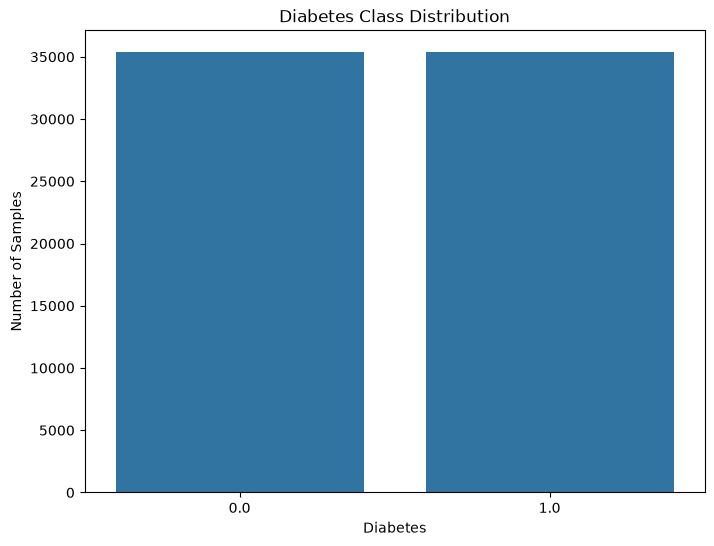

In [61]:
plt.figure(figsize=(8,6))
sns.countplot(data=df , x=df["Diabetes_binary"])
plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Number of Samples")

plt.show()

### Target Distribution

The target classes are perfectly balanced, with 35,346 samples in each class. This 50/50 distribution is consistent with the 5050-split version of the dataset and means that both classes are equally represented.

## Feature Distributions

Let's visualize the distributions of the input features to identify their ranges and general patterns.

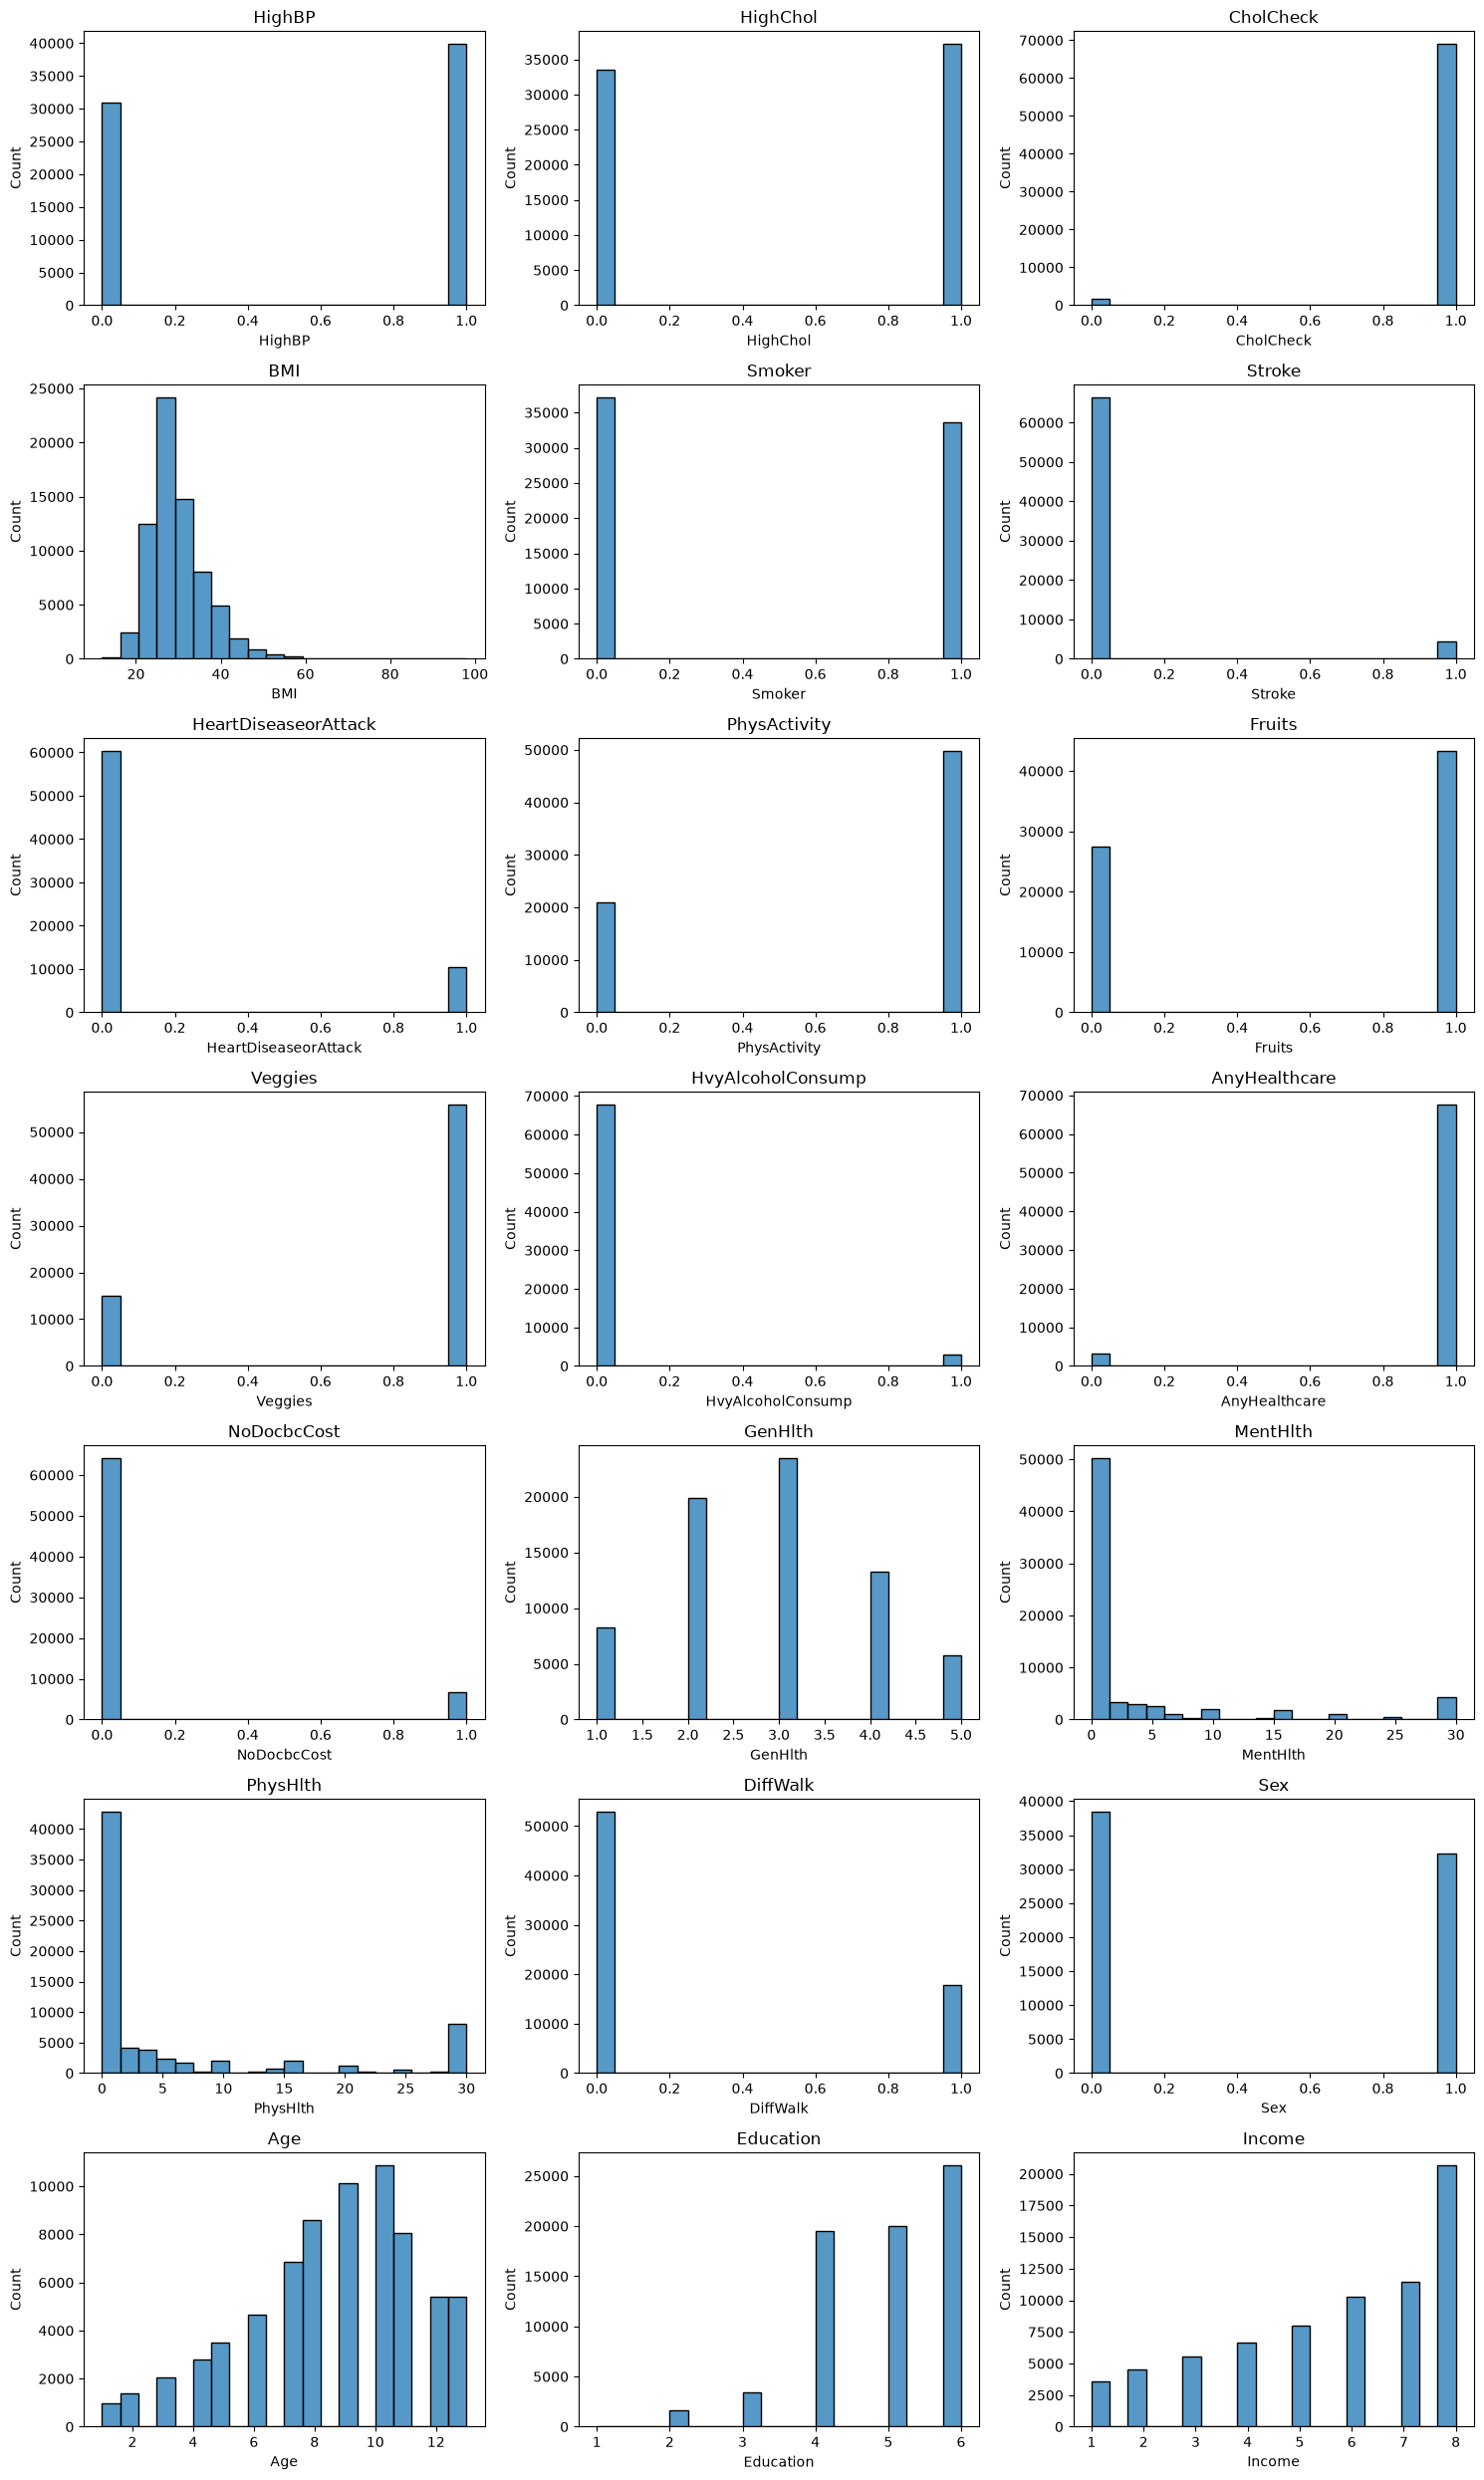

In [62]:
fig, axes = plt.subplots(7, 3, figsize=(15, 25))

for ax, column in zip(axes.flat, feature_columns):
    sns.histplot(data=df, x=column, ax=ax, bins=20)
    ax.set_title(column)

# Hide unused subplot axes, if any
for ax in axes.flat[len(feature_columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Feature Distribution Observations

Most features are binary, while `BMI`, `MentHlth`, `PhysHlth`, `Age`, `Education`, and `Income` contain multiple values. Several features are concentrated around a small number of values, which will be important to consider during preprocessing.

## Feature Correlations

Let's examine the correlations between the features and the diabetes target to identify potentially useful relationships.

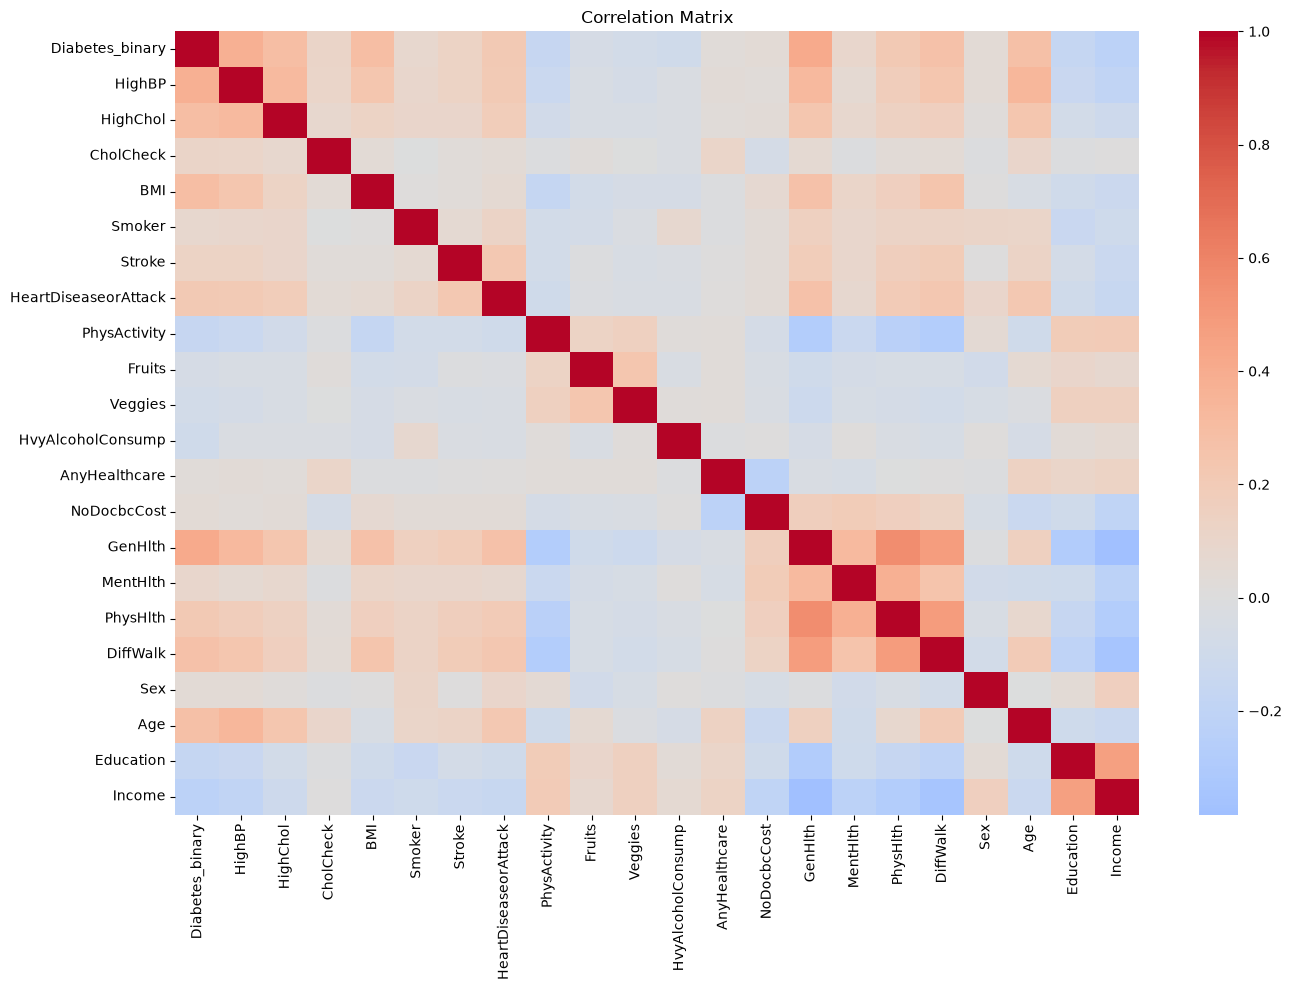

In [63]:
correlation_matrix = df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Correlation Observations

`GenHlth`, `HighBP`, `HighChol`, `BMI`, `DiffWalk`, and `Age` show relatively stronger positive correlations with the diabetes target. Some health and socioeconomic features are also correlated with each other, but no extremely strong feature-to-feature correlations are apparent.

## Correlation with the Target

Let's rank the features by their correlation with the diabetes target to identify the strongest linear relationships.

In [64]:
target_correlations = (
    df.corr()["Diabetes_binary"]
    .drop("Diabetes_binary")
    .sort_values(ascending=False)
)

print(target_correlations)

GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Stroke                  0.125427
CholCheck               0.115382
MentHlth                0.087029
Smoker                  0.085999
Sex                     0.044413
NoDocbcCost             0.040977
AnyHealthcare           0.023191
Fruits                 -0.054077
Veggies                -0.079293
HvyAlcoholConsump      -0.094853
PhysActivity           -0.158666
Education              -0.170481
Income                 -0.224449
Name: Diabetes_binary, dtype: float64


### Target Correlation Observations

`GenHlth` and `HighBP` have the strongest positive correlations with the target, followed by `BMI`, `HighChol`, and `Age`. `Income`, `Education`, and `PhysActivity` show the strongest negative correlations. These are linear relationships and do not by themselves determine feature importance for the ANN.

## Feature Comparison by Diabetes Class

Let's compare a few important features across the two diabetes classes to see how their distributions differ.

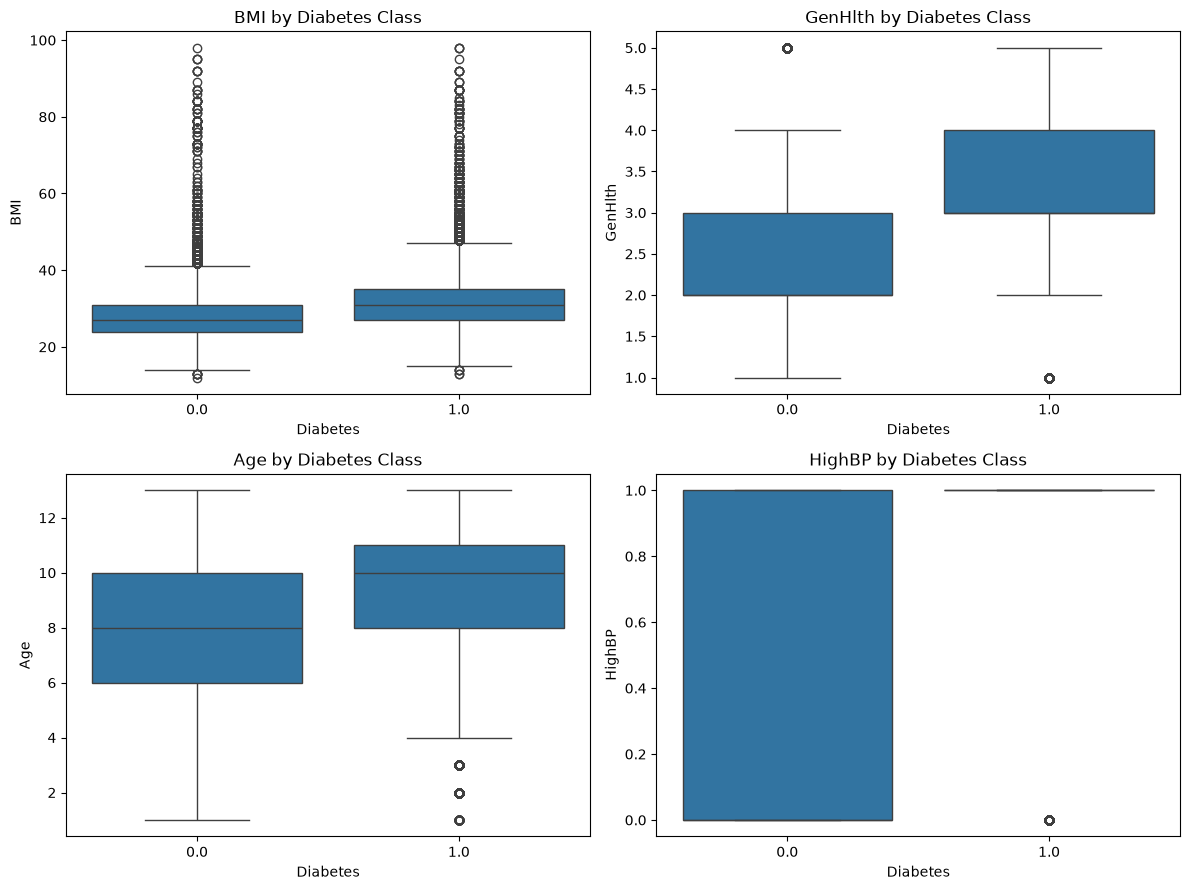

In [65]:
selected_features = ["BMI", "GenHlth", "Age", "HighBP"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.flat, selected_features):
    sns.boxplot(
        data=df,
        x="Diabetes_binary",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by Diabetes Class")
    ax.set_xlabel("Diabetes")

plt.tight_layout()
plt.show()

### Feature Comparison

The diabetic and non-diabetic groups show noticeable differences in `BMI`, `GenHlth`, `Age`, and `HighBP`. These differences suggest that these features may provide useful information for distinguishing between the two target classes.

## Duplicate Handling

The dataset contains 1,635 duplicate rows. Since identical feature values can represent different observations, we will retain these rows rather than removing them without evidence that they are erroneous duplicates.

## Separating Features and Target

We will separate the 21 input features from the `Diabetes_binary` target before splitting the data.

In [66]:
X = df[feature_columns]
y = df[target_column]

print(f"features shapes {X.shape}")
print(f"target shape {y.shape}")

features shapes (70692, 21)
target shape (70692,)


## Train, Validation, and Test Split

We will split the data into training, validation, and test sets while maintaining the same class distribution in each set.

In [67]:
X_train , X_temp , y_train , y_temp = train_test_split( X , y , test_size=0.30 , random_state=SEED , 
                                                       stratify=y
)

X_val ,X_test , y_val , y_test  = train_test_split(X_temp , y_temp ,test_size=0.50 ,  random_state=SEED,
                                                    stratify=y_temp)


In [68]:
print(f"Training set:   {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set:       {X_test.shape}, {y_test.shape}")

Training set:   (49484, 21), (49484,)
Validation set: (10604, 21), (10604,)
Test set:       (10604, 21), (10604,)


### Data Split

The dataset has been divided into 70% training, 15% validation, and 15% test data. Stratification was used to preserve the balanced target distribution across all three sets.

## Verifying Class Distribution

Let's confirm that the training, validation, and test sets have similar target distributions after the split.

In [69]:
print("training set : ")
print(y_train.value_counts(normalize=True)*100)
print("validation set ")
print(y_val.value_counts(normalize=True)*100)
print("testing set ")
print(y_test.value_counts(normalize=True)*100)

training set : 
Diabetes_binary
1.0    50.0
0.0    50.0
Name: proportion, dtype: float64
validation set 
Diabetes_binary
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64
testing set 
Diabetes_binary
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


### Class Distribution Verification

The training, validation, and test sets all maintain the original 50/50 class distribution. Stratification successfully preserved the balance of the target variable.

## Feature Scaling

Neural networks generally train more effectively when input features are on comparable scales. We will use `StandardScaler` for this preprocessing step.

## Fitting the Scaler

We will fit `StandardScaler` using only the training features. The validation and test sets will not be used to calculate the scaling parameters.

In [70]:
scaler = StandardScaler()

scaler.fit(X_train)

StandardScaler()

## Transforming the Features

We will use the training-based scaling parameters to transform the training, validation, and test features.

In [71]:
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training set:   {X_train_scaled.shape}")
print(f"Validation set: {X_val_scaled.shape}")
print(f"Test set:       {X_test_scaled.shape}")

Training set:   (49484, 21)
Validation set: (10604, 21)
Test set:       (10604, 21)


### Scaling Check

The training, validation, and test sets retain their original shapes after scaling. All 21 features have been transformed using the scaling parameters learned from the training set.

## Verifying Feature Scaling

Let's verify that the training features are centered around zero with a standard deviation close to one after scaling.

In [72]:
print(X_train_scaled.mean())
print(X_train_scaled.std())

6.106010822485858e-17
1.0


## Saving the Scaler

We will save the fitted scaler so the same preprocessing can be applied to new data during inference.

In [73]:
scaler_path = "../models/scaler.joblib"

joblib.dump(scaler, scaler_path)

print(f"Scaler saved to: {scaler_path}")

Scaler saved to: ../models/scaler.joblib


### Scaler Saved

The fitted scaler has been saved to the `models` folder. We can reuse it later to apply the same preprocessing to new data.

## Creating a PyTorch Dataset

We will create a custom `Dataset` class to store the scaled features and labels in a format that PyTorch can use with a `DataLoader`.

In [74]:
class DiabetesDataset(Dataset):
    def __init__(self , featuers , labels):
        self.features = torch.tensor(featuers , dtype=torch.float32)

        self.labels = torch.tensor(labels.to_numpy() , dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index] , self.labels[index]

    
        

## Creating Dataset Objects

Now we will create separate Dataset objects for the training, validation, and test sets using the Dataset class defined above.

In [75]:
train_dataset = DiabetesDataset(X_train_scaled , y_train)
test_dataset = DiabetesDataset(X_test_scaled , y_test)
val_dataset = DiabetesDataset(X_val_scaled , y_val)


## Creating DataLoaders

We will divide the training, validation, and test datasets into mini-batches using PyTorch DataLoaders. The training data will be shuffled, while validation and test data will keep a fixed order.

In [76]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          generator=dataloader_generator, worker_init_fn=seed_worker
)

val_loader = DataLoader( val_dataset, batch_size=batch_size, shuffle=False)

test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [77]:
X_batch, y_batch = next(iter(train_loader))

print("Feature batch shape:", X_batch.shape)
print("Label batch shape:", y_batch.shape)



Feature batch shape: torch.Size([64, 21])
Label batch shape: torch.Size([64])


### DataLoader Verification

The DataLoader is correctly returning batches of 64 samples. Each feature batch contains 21 input features, with one corresponding label for each sample.

## Building the ANN

We will create a small baseline neural network for binary classification. The network will use two hidden layers with ReLU activation and one output neuron.

In [78]:
input_size = X_train.shape[1]
input_size

21

In [79]:
class DiabetesANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size , 64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)

        )
    def forward(self , x):
        return self.network(x)

    

## Checking the ANN Architecture

Let's display the model to verify its layers and connections before training.

In [80]:
model = DiabetesANN()
print(model)

DiabetesANN(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


### ANN Architecture Check

The baseline ANN contains two hidden layers with 64 and 32 neurons, followed by one output neuron for binary classification. ReLU is used between the linear layers.

## Defining the Loss Function

The ANN produces one logit for each sample. We will use `BCEWithLogitsLoss` to calculate the binary classification loss in a numerically stable way.

In [81]:
criterion = nn.BCEWithLogitsLoss()
print(criterion)

BCEWithLogitsLoss()


### Loss Function

`BCEWithLogitsLoss` will be used for our binary classification task. It works directly with the single logit produced by the ANN and combines sigmoid activation with binary cross-entropy in a numerically stable way.

## Moving the Model to the Device

We will move the ANN to the device selected by PyTorch. This allows the same code to work on either CPU or GPU.

In [82]:
model = model.to(device)

print("Model device:", next(model.parameters()).device)

Model device: cpu


## Setting Up the Baseline Training

We will train the ANN using Adam and a learning rate of 0.001. During each epoch, the model will learn from the training batches and then be evaluated on the validation set.

In [83]:
optimizer = torch.optim.Adam(model.parameters() , lr=0.001)
num_epochs = 20

## Training the Model

For each training batch, the ANN will make predictions, calculate the loss, compute gradients through backpropagation, and update its weights using the optimizer.

In [84]:
model.train()
train_loss = 0.0

for X_batch , y_batch in train_loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)
    y_batch = y_batch.unsqueeze(1)
    optimizer.zero_grad()
    outputs = model(X_batch)
    loss = criterion(outputs , y_batch)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()    
train_loss /= len(train_loader)

print(f"training loss : {train_loss}")

training loss : 0.5176548333670126


### First Training Epoch

The ANN completed one training epoch with a training loss of approximately 0.518. The training loop is working, and the model has successfully updated its weights using backpropagation and the Adam optimizer.

## Validating the Model

After training on the batches, we will evaluate the model on the validation set. This helps us monitor how well the model performs on data it did not use to update its weights.

In [43]:
model.eval()

val_loss = 0.0

with torch.no_grad():
    for X_batch , y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_batch = y_batch.unsqueeze(1)

        outputs = model(X_batch)
        loss = criterion(outputs , y_batch)
        val_loss += loss.item()

val_loss /= len(val_loader)

print(f"validation loss : {val_loss}")

validation loss : 0.5047423354832523


### Validation Check

After the first training epoch, the validation loss was approximately 0.505. The validation loop is working correctly and allows us to monitor the model's performance on data that was not used to update its weights.

## Training the Baseline ANN

We will now combine the training and validation steps into a complete 20-epoch training loop. We will track both loss and accuracy to understand how the model learns over time.

In [44]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_batch = y_batch.unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()

        train_correct += (predictions == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_batch = y_batch.unsqueeze(1)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            val_correct += (predictions == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss /= len(val_loader)
    val_accuracy = val_correct / val_total

    # Store results
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/20] | Train Loss: 0.5037 | Val Loss: 0.5015 | Train Acc: 0.7536 | Val Acc: 0.7548
Epoch [2/20] | Train Loss: 0.5004 | Val Loss: 0.5018 | Train Acc: 0.7549 | Val Acc: 0.7530
Epoch [3/20] | Train Loss: 0.4996 | Val Loss: 0.5023 | Train Acc: 0.7558 | Val Acc: 0.7540
Epoch [4/20] | Train Loss: 0.4981 | Val Loss: 0.5015 | Train Acc: 0.7566 | Val Acc: 0.7537
Epoch [5/20] | Train Loss: 0.4972 | Val Loss: 0.5030 | Train Acc: 0.7567 | Val Acc: 0.7515
Epoch [6/20] | Train Loss: 0.4965 | Val Loss: 0.5032 | Train Acc: 0.7567 | Val Acc: 0.7527
Epoch [7/20] | Train Loss: 0.4958 | Val Loss: 0.5019 | Train Acc: 0.7581 | Val Acc: 0.7513
Epoch [8/20] | Train Loss: 0.4952 | Val Loss: 0.5031 | Train Acc: 0.7573 | Val Acc: 0.7512
Epoch [9/20] | Train Loss: 0.4945 | Val Loss: 0.5034 | Train Acc: 0.7596 | Val Acc: 0.7511
Epoch [10/20] | Train Loss: 0.4939 | Val Loss: 0.5039 | Train Acc: 0.7584 | Val Acc: 0.7529
Epoch [11/20] | Train Loss: 0.4928 | Val Loss: 0.5032 | Train Acc: 0.7591 | Val Acc: 0.75

### Baseline Training Results

The baseline ANN learned steadily on the training data, but validation performance remained relatively stable and began to fluctuate as training continued. The best validation accuracy was 75.48%, while the final training accuracy reached 76.29%. This suggests that further training provides limited improvement on unseen data.

## Checking Optuna

Before building the hyperparameter optimization process, we will verify that Optuna is installed and available in the project environment.

In [45]:
print("Optuna version:", optuna.__version__)

Optuna version: 4.9.0


## Creating a Flexible ANN

Our baseline ANN has fixed layer sizes. For Optuna, we need a model whose architecture can change based on the hyperparameters selected for each trial.

In [46]:
class OptunaDiabetesANN(nn.Module):

    def __init__(self, input_size, hidden_size_1, hidden_size_2, dropout):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size_2, 1)
        )

    def forward(self, x):
        return self.network(x)

## Defining the Optuna Objective

The objective function will run one complete ANN experiment for each Optuna trial. It will use the suggested hyperparameters, train the model, and return the validation ROC-AUC score.

In [47]:
from sklearn.metrics import roc_auc_score


def objective(trial):


    hidden_size_1 = trial.suggest_int(
        "hidden_size_1",
        32,
        128,
        step=32
    )

    hidden_size_2 = trial.suggest_int(
        "hidden_size_2",
        16,
        64,
        step=16
    )

    dropout = trial.suggest_float(
        "dropout",
        0.0,
        0.3,
        step=0.1
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    
    train_loader_trial = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=dataloader_generator,
        worker_init_fn=seed_worker
    )

    val_loader_trial = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )


    model = OptunaDiabetesANN(
        input_size=input_size,
        hidden_size_1=hidden_size_1,
        hidden_size_2=hidden_size_2,
        dropout=dropout
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

  
    for epoch in range(10):

        model.train()

        for X_batch, y_batch in train_loader_trial:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_batch = y_batch.unsqueeze(1)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

  
    model.eval()

    val_probabilities = []
    val_labels = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader_trial:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            probabilities = torch.sigmoid(outputs)

            val_probabilities.extend(
                probabilities.cpu().numpy().ravel()
            )

            val_labels.extend(
                y_batch.numpy()
            )

    val_auc = roc_auc_score(
        val_labels,
        val_probabilities
    )

    return val_auc

## Running Optuna

We will run multiple trials and let Optuna search for a hyperparameter combination that gives the best validation ROC-AUC.

In [48]:
sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(
    direction="maximize",
    study_name="diabetes_ann_optimization",
    sampler=sampler
)

study.optimize(
    objective,
    n_trials=20
)

[I 2026-08-18 21:36:01,597] A new study created in memory with name: diabetes_ann_optimization
[I 2026-08-18 21:36:16,291] Trial 0 finished with value: 0.8303669775225564 and parameters: {'hidden_size_1': 64, 'hidden_size_2': 64, 'dropout': 0.2, 'learning_rate': 0.0015751320499779737, 'weight_decay': 2.9380279387035354e-06, 'batch_size': 128}. Best is trial 0 with value: 0.8303669775225564.
[I 2026-08-18 21:36:58,506] Trial 1 finished with value: 0.8260120235333926 and parameters: {'hidden_size_1': 96, 'hidden_size_2': 48, 'dropout': 0.0, 'learning_rate': 0.008706020878304856, 'weight_decay': 0.0003142880890840109, 'batch_size': 32}. Best is trial 0 with value: 0.8303669775225564.
[I 2026-08-18 21:37:15,747] Trial 2 finished with value: 0.8299023762909621 and parameters: {'hidden_size_1': 64, 'hidden_size_2': 48, 'dropout': 0.1, 'learning_rate': 0.0003823475224675188, 'weight_decay': 6.847920095574779e-05, 'batch_size': 128}. Best is trial 0 with value: 0.8303669775225564.
[I 2026-08-1

### Optuna Results

Optuna completed 20 trials and found a best validation ROC-AUC of 0.8309. The selected configuration uses 96 and 32 neurons in the hidden layers, with 0.2 dropout, a learning rate of approximately 0.00121, and a small weight decay.

## Inspecting the Best Optuna Trial

We will retrieve the best trial and its hyperparameters so we can use the selected configuration for the final model.

In [49]:
print("Best trial:", study.best_trial.number)
print("Best validation ROC-AUC:", study.best_value)
print("Best hyperparameters:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best trial: 12
Best validation ROC-AUC: 0.8308586675974461
Best hyperparameters:
hidden_size_1: 96
hidden_size_2: 32
dropout: 0.2
learning_rate: 0.0012123634441485443
weight_decay: 3.0210752570094987e-06
batch_size: 128


## Optuna Optimization History

The optimization history shows how the validation ROC-AUC changed across trials and helps us see whether the search found better configurations over time.

C:\Users\pc\AppData\Local\Temp\ipykernel_18120\3793616265.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


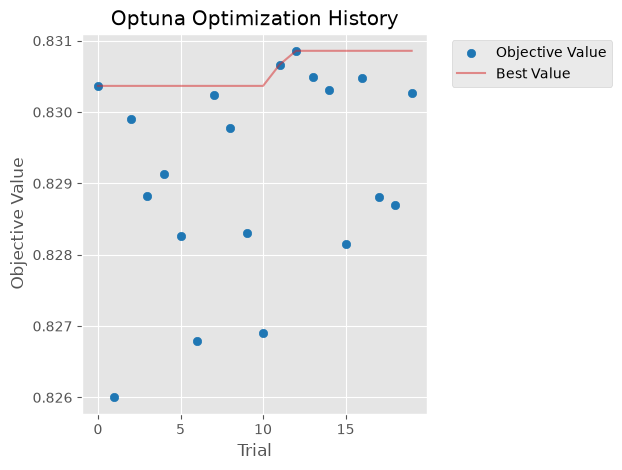

In [50]:
optuna.visualization.matplotlib.plot_optimization_history(study)

plt.title("Optuna Optimization History")
plt.tight_layout()
plt.show()

## Training the Final ANN

We will create a fresh ANN using the best hyperparameters found by Optuna. Early stopping will be used to keep the model from continuing to train after validation performance stops improving.

In [51]:
best_params = study.best_params

final_model = OptunaDiabetesANN(
    input_size=input_size,
    hidden_size_1=best_params["hidden_size_1"],
    hidden_size_2=best_params["hidden_size_2"],
    dropout=best_params["dropout"]
).to(device)

final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=best_params["learning_rate"],
    weight_decay=best_params["weight_decay"]
)

final_criterion = nn.BCEWithLogitsLoss()

final_train_loader = DataLoader(
    train_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True,
    generator=dataloader_generator,
    worker_init_fn=seed_worker
)

final_val_loader = DataLoader(
    val_dataset,
    batch_size=best_params["batch_size"],
    shuffle=False
)

print(final_model)

OptunaDiabetesANN(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=96, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=96, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training with Early Stopping

The final model will be trained using the best Optuna hyperparameters. We will monitor validation loss and keep the model weights from the best-performing epoch.

In [52]:
import copy

num_epochs = 50
patience = 5

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    final_model.train()

    train_loss = 0.0

    for X_batch, y_batch in final_train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_batch = y_batch.unsqueeze(1)

        final_optimizer.zero_grad()

        outputs = final_model(X_batch)

        loss = final_criterion(outputs, y_batch)

        loss.backward()

        final_optimizer.step()

        train_loss += loss.item()

    train_loss /= len(final_train_loader)

    # -------------------------
    # Validation
    # -------------------------
    final_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in final_val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_batch = y_batch.unsqueeze(1)

            outputs = final_model(X_batch)

            loss = final_criterion(outputs, y_batch)

            val_loss += loss.item()

    val_loss /= len(final_val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # -------------------------
    # Early stopping
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_model_state = copy.deepcopy(final_model.state_dict())
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if epochs_without_improvement >= patience:

        print("Early stopping triggered.")
        break


# Restore best model
final_model.load_state_dict(best_model_state)

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch [1/50] | Train Loss: 0.5275 | Val Loss: 0.5066
Epoch [2/50] | Train Loss: 0.5107 | Val Loss: 0.5047
Epoch [3/50] | Train Loss: 0.5077 | Val Loss: 0.5031
Epoch [4/50] | Train Loss: 0.5068 | Val Loss: 0.5024
Epoch [5/50] | Train Loss: 0.5052 | Val Loss: 0.5037
Epoch [6/50] | Train Loss: 0.5041 | Val Loss: 0.5024
Epoch [7/50] | Train Loss: 0.5032 | Val Loss: 0.5025
Epoch [8/50] | Train Loss: 0.5018 | Val Loss: 0.5015
Epoch [9/50] | Train Loss: 0.5020 | Val Loss: 0.5011
Epoch [10/50] | Train Loss: 0.5020 | Val Loss: 0.5014
Epoch [11/50] | Train Loss: 0.5013 | Val Loss: 0.5009
Epoch [12/50] | Train Loss: 0.5012 | Val Loss: 0.5014
Epoch [13/50] | Train Loss: 0.5011 | Val Loss: 0.5016
Epoch [14/50] | Train Loss: 0.4997 | Val Loss: 0.5016
Epoch [15/50] | Train Loss: 0.4992 | Val Loss: 0.5030
Epoch [16/50] | Train Loss: 0.5002 | Val Loss: 0.5020
Early stopping triggered.

Best validation loss: 0.5009


### Final Model Training

The final ANN achieved its lowest validation loss of 0.5009 at epoch 11. Validation performance stopped improving afterward, so early stopping was triggered and the best model weights were restored.

## Final Test Evaluation

The model is now finalized, so we will evaluate it on the unseen test set using multiple classification metrics.

In [53]:
final_model.eval()

test_probabilities = []
test_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = final_model(X_batch)

        probabilities = torch.sigmoid(outputs)

        test_probabilities.extend(
            probabilities.cpu().numpy().ravel()
        )

        test_labels.extend(
            y_batch.numpy()
        )

test_probabilities = np.array(test_probabilities)
test_labels = np.array(test_labels)

test_predictions = (test_probabilities >= 0.5).astype(int)

test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_precision = precision_score(
    test_labels,
    test_predictions
)

test_recall = recall_score(
    test_labels,
    test_predictions
)

test_f1 = f1_score(
    test_labels,
    test_predictions
)

test_roc_auc = roc_auc_score(
    test_labels,
    test_probabilities
)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1-score : {test_f1:.4f}")
print(f"Test ROC-AUC  : {test_roc_auc:.4f}")

Test Accuracy : 0.7523
Test Precision: 0.7239
Test Recall   : 0.8155
Test F1-score : 0.7670
Test ROC-AUC  : 0.8298


## Confusion Matrix

The confusion matrix shows how many test observations were correctly and incorrectly classified for each class.

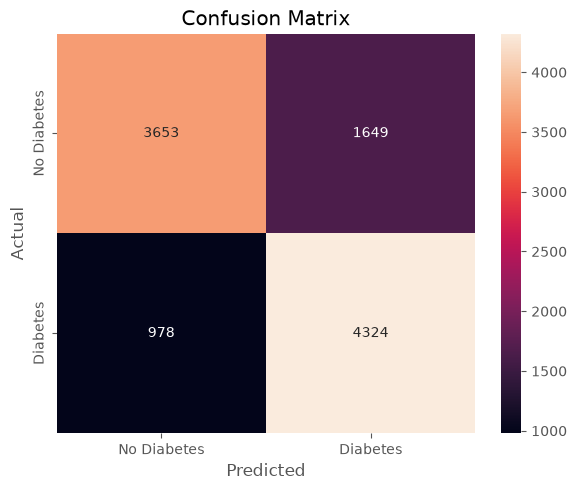

In [54]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()

plt.show()

### Confusion Matrix

The confusion matrix shows that the model correctly classified 3,653 negative cases and 4,324 positive cases. It also produced 1,649 false positives and 978 false negatives, showing that the model identifies positive cases more often than it misses them at the default 0.5 threshold.

## Classification Report

The classification report gives a detailed view of precision, recall, and F1-score for each class.

In [55]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=["No Diabetes", "Diabetes"]
    )
)

              precision    recall  f1-score   support

 No Diabetes       0.79      0.69      0.74      5302
    Diabetes       0.72      0.82      0.77      5302

    accuracy                           0.75     10604
   macro avg       0.76      0.75      0.75     10604
weighted avg       0.76      0.75      0.75     10604



### Classification Report

The model achieves a recall of 0.82 for the Diabetes class and 0.69 for the No Diabetes class. Its F1-score is 0.77 for Diabetes and 0.74 for No Diabetes, showing fairly balanced performance across both classes.

## ROC Curve

The ROC curve shows how the model's true positive rate changes against its false positive rate across different classification thresholds.

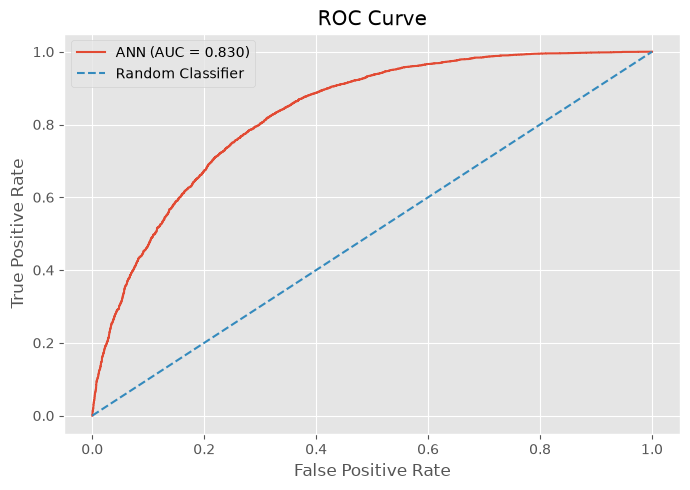

In [56]:
fpr, tpr, thresholds = roc_curve(
    test_labels,
    test_probabilities
)

auc_score = roc_auc_score(
    test_labels,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ANN (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()

plt.show()

### ROC Curve

The ROC curve gives a test ROC-AUC of 0.830, indicating reasonably strong class-separation ability. The curve also shows that the model can achieve a relatively high true positive rate while keeping the false positive rate comparatively low at some thresholds.

## Threshold Analysis

The default classification threshold is 0.5. We will use the validation set to investigate other thresholds and find a useful precision-recall trade-off before evaluating the final threshold on the test set.

## Generating Validation Probabilities

We will generate probability predictions for the validation set. These probabilities will be used to select an appropriate classification threshold.

In [57]:
final_model.eval()

val_probabilities = []
val_labels = []

with torch.no_grad():

    for X_batch, y_batch in final_val_loader:

        X_batch = X_batch.to(device)

        outputs = final_model(X_batch)

        probabilities = torch.sigmoid(outputs)

        val_probabilities.extend(
            probabilities.cpu().numpy().ravel()
        )

        val_labels.extend(
            y_batch.numpy()
        )

val_probabilities = np.array(val_probabilities)
val_labels = np.array(val_labels)

print("Validation probabilities shape:", val_probabilities.shape)
print("Validation labels shape:", val_labels.shape)

Validation probabilities shape: (10604,)
Validation labels shape: (10604,)


## Finding the Best Classification Threshold

We will compare several probability thresholds on the validation set and select the threshold that gives the highest F1-score.

In [58]:
thresholds_to_test = np.arange(0.30, 0.71, 0.05)

threshold_results = []

for threshold in thresholds_to_test:

    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        val_labels,
        predictions
    )

    recall = recall_score(
        val_labels,
        predictions
    )

    f1 = f1_score(
        val_labels,
        predictions
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

   threshold  precision    recall        f1
0       0.30   0.651523  0.935873  0.768230
1       0.35   0.667722  0.915315  0.772156
2       0.40   0.686459  0.894002  0.776604
3       0.45   0.706899  0.863825  0.777523
4       0.50   0.725631  0.818559  0.769299
5       0.55   0.748061  0.763863  0.755879
6       0.60   0.766098  0.702376  0.732854
7       0.65   0.787815  0.631648  0.701141
8       0.70   0.806443  0.543003  0.649008


### Threshold Selection

The validation results show a clear precision-recall trade-off as the classification threshold changes. Among the tested thresholds, 0.45 produced the highest F1-score (0.7775), with 0.40 close behind at 0.7766. We selected 0.40 for the final threshold evaluation to favor recall while keeping the F1-score close to its peak.

## Final Evaluation with the Selected Threshold

The threshold was selected using the validation set. We will now apply the selected threshold of 0.40 to the unseen test set and compare it with the default 0.50 threshold.

In [59]:
selected_threshold = 0.40

test_predictions_040 = (
    test_probabilities >= selected_threshold
).astype(int)

test_precision_040 = precision_score(
    test_labels,
    test_predictions_040
)

test_recall_040 = recall_score(
    test_labels,
    test_predictions_040
)

test_f1_040 = f1_score(
    test_labels,
    test_predictions_040
)

test_accuracy_040 = accuracy_score(
    test_labels,
    test_predictions_040
)

print(f"Threshold : {selected_threshold}")
print(f"Accuracy  : {test_accuracy_040:.4f}")
print(f"Precision : {test_precision_040:.4f}")
print(f"Recall    : {test_recall_040:.4f}")
print(f"F1-score  : {test_f1_040:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")

Threshold : 0.4
Accuracy  : 0.7416
Precision : 0.6853
Recall    : 0.8936
F1-score  : 0.7757
ROC-AUC   : 0.8298


### Final Threshold Evaluation

The threshold selected using validation data was 0.40. On the unseen test set, it increased recall from 81.55% to 89.36% and F1-score from 76.70% to 77.57%, while precision and accuracy decreased slightly. This demonstrates the trade-off between identifying more positive cases and producing more false positives.

## Threshold Comparison

We will compare the default 0.50 threshold with the selected 0.40 threshold to summarize the effect of threshold selection on the final test results.

In [60]:
threshold_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Threshold 0.50": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ],
    "Threshold 0.40": [
        test_accuracy_040,
        test_precision_040,
        test_recall_040,
        test_f1_040,
        test_roc_auc
    ]
})

print(threshold_comparison)

      Metric  Threshold 0.50  Threshold 0.40
0   Accuracy        0.752263        0.741607
1  Precision        0.723924        0.685276
2     Recall        0.815541        0.893625
3   F1-score        0.767007        0.775704
4    ROC-AUC        0.829790        0.829790


### Threshold Comparison

The 0.40 threshold improves recall and F1-score compared with the default 0.50 threshold, while accuracy and precision decrease slightly. Since the threshold was selected using validation data, 0.40 will be used as the final threshold for inference.

## Saving the Final Model

The final model weights will be saved so the trained ANN can be loaded later without retraining it.

In [61]:
model_path = "../models/diabetes_ann_model.pth"

torch.save(
    final_model.state_dict(),
    model_path
)

print(f"Model saved to: {model_path}")

Model saved to: ../models/diabetes_ann_model.pth


## Saving Model Configuration

The selected threshold and best Optuna hyperparameters will be saved so the final model can be reproduced and used later without relying on notebook variables.

In [62]:
import json

model_config = {
    "threshold": selected_threshold,
    "input_size": input_size,
    "hidden_size_1": best_params["hidden_size_1"],
    "hidden_size_2": best_params["hidden_size_2"],
    "dropout": best_params["dropout"],
    "learning_rate": best_params["learning_rate"],
    "weight_decay": best_params["weight_decay"],
    "batch_size": best_params["batch_size"]
}

config_path = "../models/model_config.json"

with open(config_path, "w") as file:
    json.dump(model_config, file, indent=4)

print(f"Configuration saved to: {config_path}")

Configuration saved to: ../models/model_config.json


## Model Inference

We will create a function that takes new patient features, applies the same preprocessing used during training, and returns the predicted probability and class.

In [63]:
def predict_diabetes(patient_data):

    # Convert input into a DataFrame
    patient_df = pd.DataFrame(
        [patient_data],
        columns=feature_columns
    )

    # Apply the fitted scaler
    patient_scaled = scaler.transform(patient_df)

    # Convert to PyTorch tensor
    patient_tensor = torch.tensor(
        patient_scaled,
        dtype=torch.float32
    ).to(device)

    # Evaluation mode
    final_model.eval()

    with torch.no_grad():

        # Get model output (logit)
        output = final_model(patient_tensor)

        # Convert logit to probability
        probability = torch.sigmoid(output).item()

    # Apply selected threshold
    prediction = int(
        probability >= selected_threshold
    )

    return probability, prediction

## Testing the Inference Function

We will test the inference pipeline using one observation from the test set and check the predicted probability and class.

In [64]:
# Take one real observation from the test set
sample_patient = X_test.iloc[0].to_dict()

probability, prediction = predict_diabetes(sample_patient)

print(f"Predicted probability: {probability:.4f}")
print(f"Predicted class: {prediction}")

Predicted probability: 0.4084
Predicted class: 1


## Checking the Inference Result

We will compare the model's prediction with the actual label of the selected test observation.

In [65]:
actual_label = y_test.iloc[0]

print(f"Actual class: {int(actual_label)}")
print(f"Predicted class: {prediction}")

Actual class: 0
Predicted class: 1


### Inference Test

The inference pipeline successfully processed a real test observation and returned a probability and class prediction. For this example, the model predicted diabetes with a probability of 0.4084, while the actual class was 0. This represents a false positive prediction.

## Saving Final Metrics

We will save the final threshold comparison as a CSV file so the model results can be easily reviewed and used in the project documentation.

In [66]:
metrics_path = "../results/metrics/threshold_comparison.csv"

threshold_comparison.to_csv(
    metrics_path,
    index=False
)

print(f"Metrics saved to: {metrics_path}")

Metrics saved to: ../results/metrics/threshold_comparison.csv


## Saving Final Test Metrics

We will save the final test-set metrics using the selected classification threshold of 0.40.

In [67]:
final_metrics = {
    "threshold": selected_threshold,
    "accuracy": test_accuracy_040,
    "precision": test_precision_040,
    "recall": test_recall_040,
    "f1_score": test_f1_040,
    "roc_auc": test_roc_auc
}

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

final_metrics_path = "../results/metrics/final_metrics.csv"

final_metrics_df.to_csv(
    final_metrics_path,
    index=False
)

print(f"Final metrics saved to: {final_metrics_path}")

Final metrics saved to: ../results/metrics/final_metrics.csv


## Saving the Classification Report

We will save the class-wise precision, recall and F1-score from the final test evaluation.

In [68]:
report = classification_report(
    test_labels,
    test_predictions_040,
    target_names=["No Diabetes", "Diabetes"]
)

report_path = "../results/metrics/classification_report.txt"

with open(report_path, "w") as file:
    file.write(report)

print(report)
print(f"\nClassification report saved to: {report_path}")

              precision    recall  f1-score   support

 No Diabetes       0.85      0.59      0.70      5302
    Diabetes       0.69      0.89      0.78      5302

    accuracy                           0.74     10604
   macro avg       0.77      0.74      0.74     10604
weighted avg       0.77      0.74      0.74     10604


Classification report saved to: ../results/metrics/classification_report.txt


## Final Confusion Matrix

We will create and save a confusion matrix using the final classification threshold of 0.40.

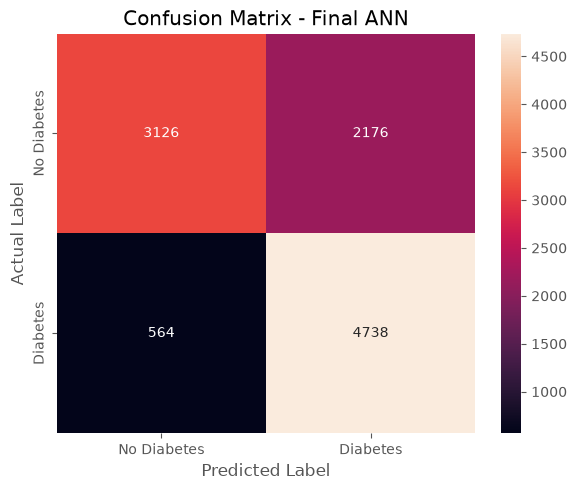

Confusion matrix saved to: ../results/figures/confusion_matrix.png


In [69]:
cm = confusion_matrix(
    test_labels,
    test_predictions_040
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Final ANN")

plt.tight_layout()

cm_path = "../results/figures/confusion_matrix.png"

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Confusion matrix saved to: {cm_path}")

## Final ROC Curve

We will create and save the ROC curve using the final model probabilities on the test set.

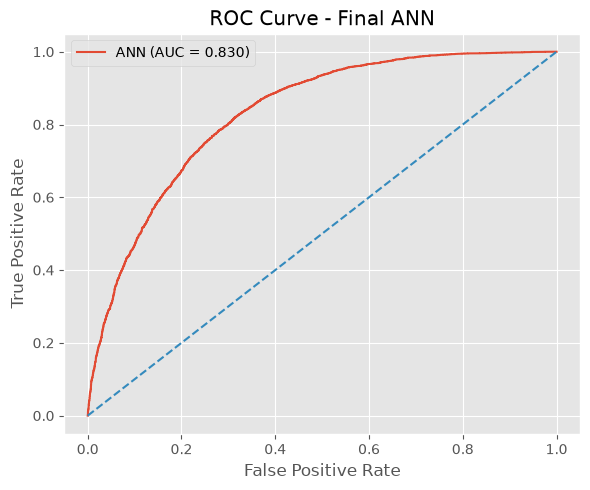

ROC curve saved to: ../results/figures/roc_curve.png


In [70]:
fpr, tpr, _ = roc_curve(
    test_labels,
    test_probabilities
)

roc_auc_value = test_roc_auc

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ANN (AUC = {roc_auc_value:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final ANN")
plt.legend()

plt.tight_layout()

roc_path = "../results/figures/roc_curve.png"

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"ROC curve saved to: {roc_path}")

## Final Training Curves

We will visualize the training and validation loss to understand how the final model learned over the training epochs.

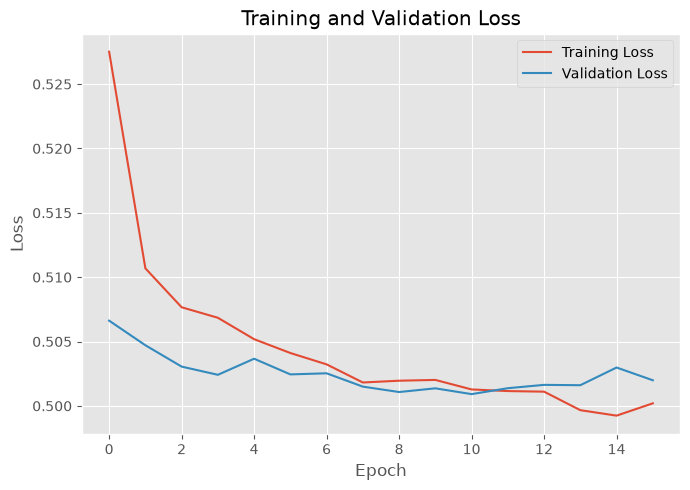

Loss curve saved to: ../results/figures/training_validation_loss.png


In [71]:
plt.figure(figsize=(7, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.tight_layout()

loss_curve_path = "../results/figures/training_validation_loss.png"

plt.savefig(
    loss_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Loss curve saved to: {loss_curve_path}")

## Project Dependencies

This project uses the following Python libraries for data processing, visualization, model training, hyperparameter tuning, and model saving.

In [72]:
import sys
import torch
import numpy
import pandas
import matplotlib
import seaborn
import sklearn
import kagglehub
import optuna
import joblib

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Optuna:", optuna.__version__)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
PyTorch: 2.13.0+cpu
NumPy: 2.5.2
Pandas: 3.0.5
Scikit-learn: 1.9.0
Optuna: 4.9.0
